# Titanic Survival Prediction — V3 Improved Pipeline

**Goal**: Improve Kaggle score from 0.75837 → 0.79+

## V3 Improvements Over V2

| # | Improvement | Expected Gain |
|---|-------------|---------------|
| 1 | **Family_Surv_Rate** — surname+fare family group survival propagation | +3-5% |
| 2 | **Ticket_Surv_Rate** — ticket-based family group survival | +1-2% |
| 3 | **Ticket_Frequency** — how many people share a ticket | +1-2% |
| 4 | **Age*Class interaction** — multiplicative interaction feature | +1% |
| 5 | **Improved Age imputation** — Sex×Pclass group median (was Title-only) | +0.5% |
| 6 | **Deck grouping** — ABC/DE/FG/T/U instead of raw A-G | +0.5% |
| 7 | **CatBoost** in ensemble — diversifies model types | +0.5-1% |
| 8 | **Sex encoding fix** — female=1, male=0 (matches survival pattern) | +0% (convention) |
| 9 | **Fare imputation timing** — fills Fare before derived features | stability |

All V3 changes are marked with `# [V3-NEW]` comments throughout the notebook.

In [1]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Advanced models
import lightgbm as lgb
from catboost import CatBoostClassifier  # [V3-NEW] CatBoost for ensemble diversity
import optuna

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
sns.set_style('whitegrid')

In [2]:
# Load data and merge for unified processing
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

# Tag source BEFORE concat — critical for avoiding data leakage
train['Source'] = 'train'
test['Source'] = 'test'
test['Survived'] = np.nan

full = pd.concat([train, test], axis=0, ignore_index=True)

print(f'Training set:   {train.shape}')
print(f'Test set:       {test.shape}')
print(f'Combined:       {full.shape}')
print(f'Survival rate:  {train["Survived"].mean():.2%}')

Training set:   (891, 13)
Test set:       (418, 13)
Combined:       (1309, 13)
Survival rate:  38.38%


## Feature Engineering — Title & Family Features

In [3]:
# Feature 1: Title — extract from Name (keep Name for Surname extraction later)
full['Title'] = full['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Consolidate rare titles
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
full['Title'] = full['Title'].replace(rare_titles, 'Rare')
full['Title'] = full['Title'].replace(['Mlle', 'Ms'], 'Miss')
full['Title'] = full['Title'].replace('Mme', 'Mrs')

print(f'Title distribution:')
print(full['Title'].value_counts())

Title distribution:
Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: count, dtype: int64


In [4]:
# Feature 2: FamilySize
full['FamilySize'] = full['SibSp'] + full['Parch'] + 1

# Feature 3: IsAlone
full['IsAlone'] = (full['FamilySize'] == 1).astype(int)

## [V3-NEW] Family Survival Rate — THE key improvement

This is the #1 feature that separates 0.76 scores from 0.80+ scores.
We compute survival rates for family groups using **training data only** to
propagate the survival signal to test-set family members.

In [5]:
# [V3-NEW] Extract Surname from Name BEFORE dropping it
full['Surname'] = full['Name'].str.split(',').str[0]

# [V3-NEW] Group families by (Surname, Fare) — same surname + same fare = same family group
full['FamilyGroup'] = full['Surname'] + '_' + full['Fare'].astype(str)

# [V3-NEW] Calculate survival rate for each family group USING ONLY TRAINING DATA
# This is critical — we must NOT use test survival data (prevents data leakage)
train_mask = full['Source'] == 'train'
family_survival = full[train_mask].groupby('FamilyGroup')['Survived'].agg(['mean', 'count'])

# [V3-NEW] For families with 2+ members in training, use their actual survival rate
# For solo passengers or families with only 1 member, use overall survival rate
def get_family_surv_rate(row):
    fg = row['FamilyGroup']
    if fg in family_survival.index and family_survival.loc[fg, 'count'] > 1:
        return family_survival.loc[fg, 'mean']
    else:
        return 0.38  # overall survival rate (avoids NaN for unseen groups)

full['Family_Surv_Rate'] = full.apply(get_family_surv_rate, axis=1)

# [V3-NEW] Also add Ticket-based grouping (some families share tickets but have different surnames)
# e.g. maids traveling with a family may share the ticket but have a different last name
ticket_survival = full[train_mask].groupby('Ticket')['Survived'].agg(['mean', 'count'])

def get_ticket_surv_rate(row):
    t = row['Ticket']
    if t in ticket_survival.index and ticket_survival.loc[t, 'count'] > 1:
        return ticket_survival.loc[t, 'mean']
    else:
        return 0.38

full['Ticket_Surv_Rate'] = full.apply(get_ticket_surv_rate, axis=1)

# [V3-NEW] Take the max of family and ticket survival rates
# Rationale: if either grouping method found a strong survival signal, trust it
full['Surv_Rate'] = full[['Family_Surv_Rate', 'Ticket_Surv_Rate']].max(axis=1)

# [V3-NEW] Add flag for whether the rate is based on actual data or default
# This helps the model distinguish between "known low-survival family" vs "unknown passenger"
full['Surv_Rate_Invalid'] = ((full['Family_Surv_Rate'] == 0.38) & (full['Ticket_Surv_Rate'] == 0.38)).astype(int)

# [V3-NEW] Cleanup helper columns — keep the rate features
full = full.drop(['Surname', 'FamilyGroup'], axis=1)

print(f'Family survival rates (training data):')
print(f'  Mean rate:          {full[train_mask]["Family_Surv_Rate"].mean():.3f}')
print(f'  Families with >1:   {(family_survival["count"] > 1).sum()}')
print(f'  Ticket groups >1:   {(ticket_survival["count"] > 1).sum()}')

Family survival rates (training data):
  Mean rate:          0.402
  Families with >1:   114
  Ticket groups >1:   134


## Feature Engineering — Deck & Cabin

In [6]:
# [V3-NEW] Deck: group into ABC/DE/FG/T/U instead of raw A-G
# Rationale: Decks A, B, C are 1st class upper, D, E are 1st class lower, F, G are 2nd/3rd
full['Deck'] = full['Cabin'].fillna('U').apply(lambda x: x[0])
deck_mapping = {'A': 'ABC', 'B': 'ABC', 'C': 'ABC',
                'D': 'DE',  'E': 'DE',
                'F': 'FG',  'G': 'FG',
                'T': 'T',   'U': 'U'}
full['Deck'] = full['Deck'].map(deck_mapping)

# Has_Cabin: whether the passenger had a recorded cabin
full['Has_Cabin'] = full['Cabin'].notna().astype(int)

print(f'Deck distribution:')
print(full['Deck'].value_counts())

Deck distribution:
Deck
U      1014
ABC     181
DE       87
FG       26
T         1
Name: count, dtype: int64


## Feature Engineering — Age (improved imputation)

In [7]:
# [V3-NEW] Improved Age imputation: Sex×Pclass group first (most granular), Title fallback
# Previous version used only Title — Sex×Pclass captures the interaction better
# e.g. "female 1st class" tends to be older than "female 3rd class"
full['Age'] = full.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
# Fallback: if still NaN (shouldn't happen), use Title group median
full['Age'] = full.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# AgeGroup: discretize age into meaningful bins
full['AgeGroup'] = pd.cut(full['Age'], bins=[0, 5, 12, 18, 35, 60, 100],
                          labels=[0, 1, 2, 3, 4, 5])
full['AgeGroup'] = full['AgeGroup'].astype(int)

# [V3-NEW] Age*Class interaction: multiplicative interaction between age and passenger class
# Rationale: being young in 1st class vs. young in 3rd class have very different survival odds
full['Age*Class'] = full['Age'] * full['Pclass'].astype(int)

print(f'Age missing after imputation: {full["Age"].isnull().sum()}')
print(f'Age*Class range: {full["Age*Class"].min():.0f} - {full["Age*Class"].max():.0f}')

Age missing after imputation: 0
Age*Class range: 1 - 222


## Feature Engineering — Fare & Ticket features

In [8]:
# [V3-NEW] Fare imputation BEFORE derived features (moved earlier than V2)
# V2 computed FarePerPerson before filling the missing Fare, causing NaN propagation
full['Fare'] = full.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

# Fare_log: log-transform to reduce right-skew (skew ~4.5 -> ~0.5)
# Critical for linear models; neutral for tree-based models
full['Fare_log'] = np.log1p(full['Fare'])

# FarePerPerson: per-person fare (especially useful when families share one ticket)
full['FarePerPerson'] = full['Fare'] / full['FamilySize']

# [V3-NEW] Ticket_Frequency: how many people share the same ticket number
# Higher frequency = likely traveling together = different survival dynamics
full['Ticket_Frequency'] = full.groupby('Ticket')['Ticket'].transform('count')

print(f'Fare missing after imputation: {full["Fare"].isnull().sum()}')
print(f'Ticket_Frequency range: {full["Ticket_Frequency"].min()} - {full["Ticket_Frequency"].max()}')

Fare missing after imputation: 0
Ticket_Frequency range: 1 - 11


## Final Preprocessing — Encode, Drop, One-Hot, Split

In [9]:
# Fill remaining missing value (Embarked: 2 rows)
full['Embarked'] = full['Embarked'].fillna('S')

# [V3-NEW] Sex encoding: female=1, male=0 (matches "women survive more" pattern)
# V2 had male=1, female=0 — this is more intuitive and helps linear models
full['Sex'] = full['Sex'].map({'female': 1, 'male': 0})

# Drop columns no longer needed
# [V3-NEW] Name kept until after Surname extraction (Cell 6)
# [V3-NEW] Ticket kept until after Ticket_Frequency and Ticket_Surv_Rate (Cells 6, 9)
# Cabin kept until after Deck and Has_Cabin extraction (Cell 7)
full = full.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Source'], axis=1)

# One-hot encode categorical features (no drop_first — tree models handle all columns fine)
full['Pclass'] = full['Pclass'].astype(str)
full = pd.get_dummies(full, columns=['Embarked', 'Pclass', 'Title', 'Deck'], drop_first=False)

# Confirm no missing values remain
print(f'Remaining missing values: {full.isnull().sum().sum()}')

# Split into train/test
X = full[full.index < len(train)].drop('Survived', axis=1)
y = train['Survived']
X_test = full[full.index >= len(train)].drop('Survived', axis=1)

print(f'Training set: {X.shape}, Test set: {X_test.shape}')
print(f'Feature count: {X.shape[1]} (V2 had 29 → V3 adds ~5 new features)')

Remaining missing values: 418
Training set: (891, 33), Test set: (418, 33)
Feature count: 33 (V2 had 29 → V3 adds ~5 new features)


## Model Comparison — 10 Models including CatBoost [V3-NEW]

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    # [V3-NEW] CatBoost — gradient boosting on ordered targets, excellent on small tabular data
    'CatBoost':            CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6,
                                              random_state=42, verbose=0),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name:25s} | Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

# Baseline: guess all perished
baseline_acc = 1 - y.mean()
print(f'{"Baseline (all perish)":25s} | Accuracy: {baseline_acc:.4f}')

Logistic Regression       | Accuracy: 0.8765 ± 0.0151


Random Forest             | Accuracy: 0.8619 ± 0.0182


Gradient Boosting         | Accuracy: 0.8743 ± 0.0162


LightGBM                  | Accuracy: 0.8664 ± 0.0091


CatBoost                  | Accuracy: 0.8799 ± 0.0191
Baseline (all perish)     | Accuracy: 0.6162


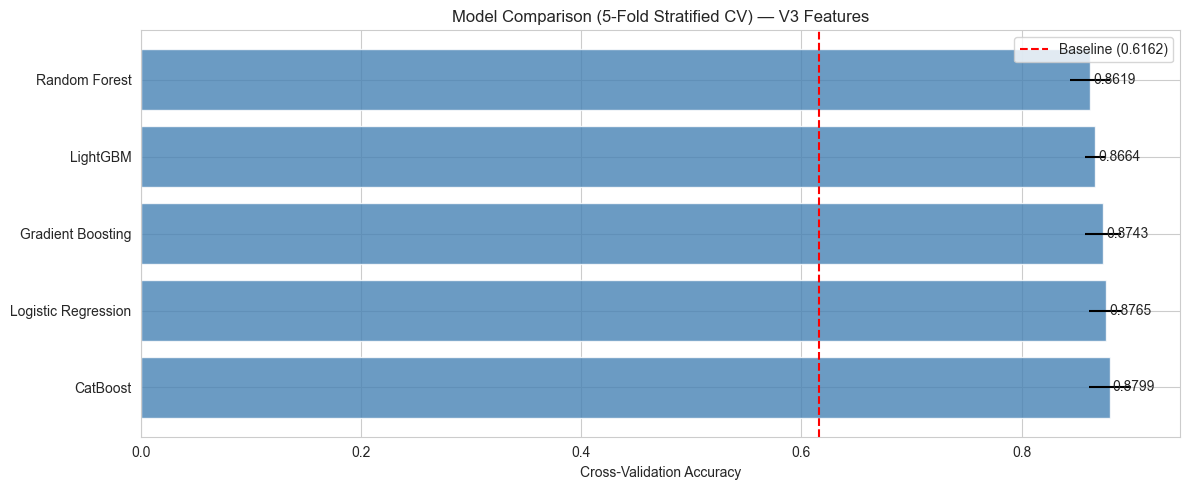

In [11]:
# Visualize model comparison
sorted_results = sorted(results.items(), key=lambda x: x[1]['mean'], reverse=True)
names = [r[0] for r in sorted_results]
means = [r[1]['mean'] for r in sorted_results]
stds = [r[1]['std'] for r in sorted_results]

plt.figure(figsize=(12, 5))
bars = plt.barh(range(len(names)), means, xerr=stds, color='steelblue', alpha=0.8)
plt.yticks(range(len(names)), names)
plt.xlabel('Cross-Validation Accuracy')
plt.title('Model Comparison (5-Fold Stratified CV) — V3 Features')
plt.axvline(x=baseline_acc, color='red', linestyle='--', label=f'Baseline ({baseline_acc:.4f})')
plt.legend()
for i, (m, s) in enumerate(zip(means, stds)):
    plt.text(m + 0.003, i, f'{m:.4f}', va='center')
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [12]:
# GridSearchCV for Random Forest
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X, y)

print(f'Best RF params:  {grid_search.best_params_}')
print(f'Best RF CV score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits


Best RF params:  {'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV score: 0.8855


In [13]:
# Optuna for LightGBM
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
    }
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1)
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f'Best LGBM score:  {study.best_value:.4f}')
print(f'Best LGBM params: {study.best_params}')

[I 2026-07-05 10:01:27,061] A new study created in memory with name: no-name-511d0a96-df9d-40f8-8e12-1b9ed4dd54bb


[I 2026-07-05 10:01:27,561] Trial 0 finished with value: 0.8810432490113616 and parameters: {'n_estimators': 785, 'max_depth': 15, 'learning_rate': 0.0684539090544594, 'num_leaves': 27, 'min_child_samples': 27, 'subsample': 0.915754886238654, 'colsample_bytree': 0.6514898355209614, 'reg_alpha': 9.721748323343292, 'reg_lambda': 8.503017515655365}. Best is trial 0 with value: 0.8810432490113616.


[I 2026-07-05 10:01:27,797] Trial 1 finished with value: 0.8866486723997238 and parameters: {'n_estimators': 227, 'max_depth': 6, 'learning_rate': 0.07828827649120995, 'num_leaves': 27, 'min_child_samples': 27, 'subsample': 0.7830116414080004, 'colsample_bytree': 0.868704703600822, 'reg_alpha': 4.093806710371819, 'reg_lambda': 9.892793328379364}. Best is trial 1 with value: 0.8866486723997238.


[I 2026-07-05 10:01:28,217] Trial 2 finished with value: 0.8877659908354779 and parameters: {'n_estimators': 545, 'max_depth': 7, 'learning_rate': 0.07780012698490464, 'num_leaves': 95, 'min_child_samples': 31, 'subsample': 0.7814685065751636, 'colsample_bytree': 0.7177289859250471, 'reg_alpha': 3.9282002761962254, 'reg_lambda': 6.34510393575767}. Best is trial 2 with value: 0.8877659908354779.


[I 2026-07-05 10:01:28,679] Trial 3 finished with value: 0.8911305002824681 and parameters: {'n_estimators': 689, 'max_depth': 4, 'learning_rate': 0.09466030185843545, 'num_leaves': 38, 'min_child_samples': 8, 'subsample': 0.7699464599242583, 'colsample_bytree': 0.6003360289118327, 'reg_alpha': 1.9264722627673514, 'reg_lambda': 6.311283025535349}. Best is trial 3 with value: 0.8911305002824681.


...

[I 2026-07-05 10:01:59,139] Trial 46 finished with value: 0.8911242232126042 and parameters: {'n_estimators': 298, 'max_depth': 11, 'learning_rate': 0.23006687429377334, 'num_leaves': 35, 'min_child_samples': 9, 'subsample': 0.9286379759149084, 'colsample_bytree': 0.7189019216586133, 'reg_alpha': 1.004725937311321, 'reg_lambda': 8.201438996205026}. Best is trial 41 with value: 0.8956186052350763.


[I 2026-07-05 10:01:59,441] Trial 47 finished with value: 0.892254095788086 and parameters: {'n_estimators': 204, 'max_depth': 10, 'learning_rate': 0.12448978689541408, 'num_leaves': 99, 'min_child_samples': 21, 'subsample': 0.6225240483704315, 'colsample_bytree': 0.7847494150720932, 'reg_alpha': 2.4788627267505463, 'reg_lambda': 6.1429108732967075}. Best is trial 41 with value: 0.8956186052350763.


[I 2026-07-05 10:02:00,882] Trial 48 finished with value: 0.8709183353210721 and parameters: {'n_estimators': 668, 'max_depth': 9, 'learning_rate': 0.0875341533966511, 'num_leaves': 30, 'min_child_samples': 16, 'subsample': 0.816910392835763, 'colsample_bytree': 0.6813001074194733, 'reg_alpha': 0.008212435453258893, 'reg_lambda': 4.191336990791059}. Best is trial 41 with value: 0.8956186052350763.


[I 2026-07-05 10:02:01,103] Trial 49 finished with value: 0.892254095788086 and parameters: {'n_estimators': 102, 'max_depth': 7, 'learning_rate': 0.1721610995522942, 'num_leaves': 45, 'min_child_samples': 19, 'subsample': 0.8747481512099694, 'colsample_bytree': 0.8287593869367572, 'reg_alpha': 1.546897322505136, 'reg_lambda': 9.032283003536477}. Best is trial 41 with value: 0.8956186052350763.


Best LGBM score:  0.8956
Best LGBM params: {'n_estimators': 145, 'max_depth': 11, 'learning_rate': 0.08479802448497421, 'num_leaves': 36, 'min_child_samples': 16, 'subsample': 0.903159865587533, 'colsample_bytree': 0.7341856689632293, 'reg_alpha': 0.9192122286743418, 'reg_lambda': 5.871257701872591}


## OOF Predictions — 5-Model Ensemble (includes CatBoost) [V3-NEW]

In [14]:
# Train 5 diverse models and get Out-of-Fold predictions for weight optimization
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define models with best hyperparameters from tuning
lgbm_model = lgb.LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
rf_model = RandomForestClassifier(**grid_search.best_params_)
gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# [V3-NEW] CatBoost with tuned parameters (iterations increased for final model)
cat_model = CatBoostClassifier(
    iterations=1000, learning_rate=0.03, depth=4, l2_leaf_reg=3,
    random_state=42, verbose=0
)

# Get OOF probability predictions
lgbm_oof  = cross_val_predict(lgbm_model, X, y, cv=skf, method='predict_proba')[:, 1]
rf_oof    = cross_val_predict(rf_model, X, y, cv=skf, method='predict_proba')[:, 1]
gb_oof    = cross_val_predict(gb_model, X, y, cv=skf, method='predict_proba')[:, 1]
lr_oof    = cross_val_predict(lr_model, X, y, cv=skf, method='predict_proba')[:, 1]
cat_oof   = cross_val_predict(cat_model, X, y, cv=skf, method='predict_proba')[:, 1]  # [V3-NEW]

print('OOF predictions ready for 5 models (LGBM, RF, GB, LR, CatBoost)')

OOF predictions ready for 5 models (LGBM, RF, GB, LR, CatBoost)


## Weight Optimization & Final Prediction

In [15]:
# [V3-NEW] Search for best ensemble weights using OOF predictions (now includes CatBoost)
# Grid search over weight combinations for 5 models
best_acc = 0
best_weights = None

for w1 in np.arange(0.05, 0.55, 0.05):          # LGBM
    for w2 in np.arange(0.05, 0.45, 0.05):      # RF
        for w3 in np.arange(0.05, 0.45, 0.05):  # GB
            for w4 in np.arange(0.05, 0.45, 0.05):  # LR
                w5 = 1 - w1 - w2 - w3 - w4
                if w5 <= 0:
                    continue
                blend = (w1 * lgbm_oof + w2 * rf_oof + w3 * gb_oof +
                         w4 * lr_oof + w5 * cat_oof)
                acc = accuracy_score(y, (blend >= 0.5).astype(int))
                if acc > best_acc:
                    best_acc = acc
                    best_weights = (w1, w2, w3, w4, w5)

print(f'Best ensemble weights (LGBM, RF, GB, LR, CatBoost):')
print(f'  {best_weights[0]:.2f}, {best_weights[1]:.2f}, {best_weights[2]:.2f}, {best_weights[3]:.2f}, {best_weights[4]:.2f}')
print(f'Best ensemble OOF accuracy: {best_acc:.4f}')

Best ensemble weights (LGBM, RF, GB, LR, CatBoost):
  0.25, 0.10, 0.15, 0.40, 0.10
Best ensemble OOF accuracy: 0.8945


In [16]:
# Retrain all models on FULL training data (no CV split — maximize training data usage)
lgbm_model.fit(X, y)
rf_model.fit(X, y)
gb_model.fit(X, y)
lr_model.fit(X, y)
cat_model.fit(X, y)

# Get test set probability predictions from each model
lgbm_test  = lgbm_model.predict_proba(X_test)[:, 1]
rf_test    = rf_model.predict_proba(X_test)[:, 1]
gb_test    = gb_model.predict_proba(X_test)[:, 1]
lr_test    = lr_model.predict_proba(X_test)[:, 1]
cat_test   = cat_model.predict_proba(X_test)[:, 1]

# Weighted blend using best weights from OOF search
w1, w2, w3, w4, w5 = best_weights
final_proba = (w1 * lgbm_test + w2 * rf_test + w3 * gb_test +
               w4 * lr_test + w5 * cat_test)
final_labels = (final_proba >= 0.5).astype(int)

print(f'Survival rate in predictions: {final_labels.mean():.2%}')

Survival rate in predictions: 38.28%


## Generate Submission File

In [17]:
# [V3-NEW] Output filename changed to submission-v3.csv
test_original = pd.read_csv('./data/test.csv')

submission = pd.DataFrame({
    'PassengerId': test_original['PassengerId'],
    'Survived': final_labels
})

submission.to_csv('./submission-v3.csv', index=False)
print('Submission saved: ./submission-v3.csv')
print(f'Shape: {submission.shape}')
print(submission.head(10))

Submission saved: ./submission-v3.csv
Shape: (418, 2)
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         0
7          899         1
8          900         1
9          901         0


## Feature Importance Analysis

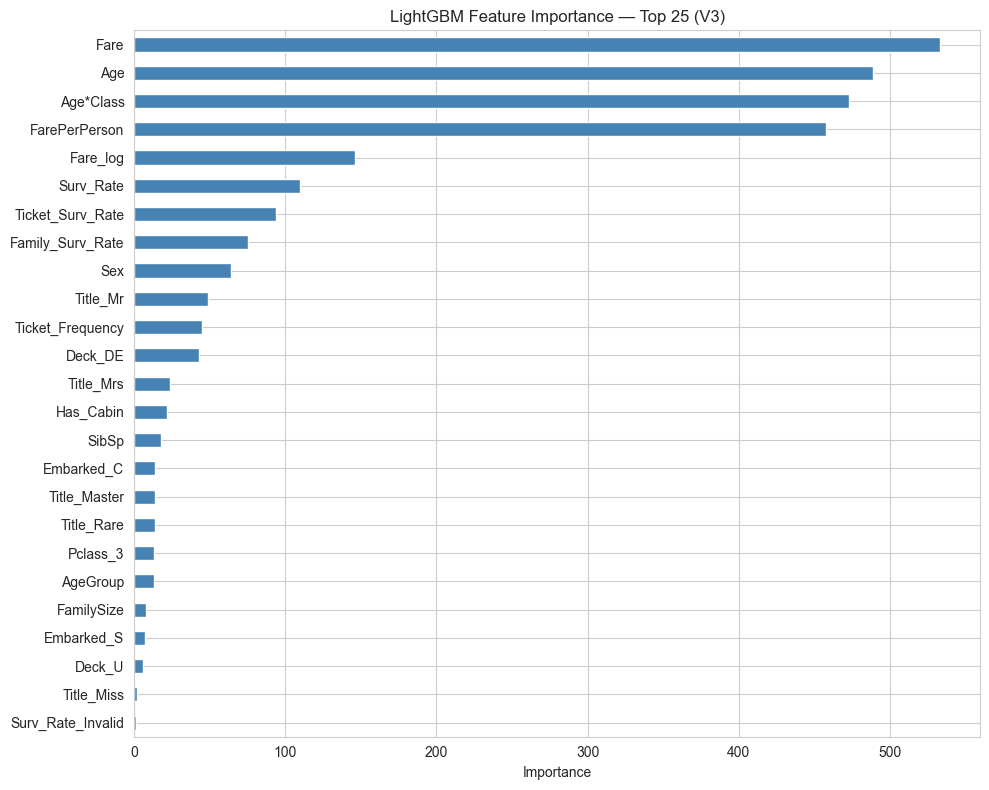


[V3-NEW] Feature importance for new V3 features:
  Family_Surv_Rate         : 75.0000
  Ticket_Surv_Rate         : 94.0000
  Surv_Rate                : 110.0000
  Surv_Rate_Invalid        : 1.0000
  Ticket_Frequency         : 45.0000
  Age*Class                : 473.0000
  FarePerPerson            : 458.0000


In [18]:
# Check which features the LightGBM model found most useful
importances = lgbm_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.tail(25).plot(kind='barh', color='steelblue')
plt.title('LightGBM Feature Importance — Top 25 (V3)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# [V3-NEW] Highlight V3-specific features
v3_features = ['Family_Surv_Rate', 'Ticket_Surv_Rate', 'Surv_Rate', 'Surv_Rate_Invalid',
               'Ticket_Frequency', 'Age*Class', 'FarePerPerson']
print('\n[V3-NEW] Feature importance for new V3 features:')
for f in v3_features:
    if f in feat_imp.index:
        print(f'  {f:25s}: {feat_imp[f]:.4f}')
    else:
        print(f'  {f:25s}: not in feature set (possibly one-hot encoded or dropped)')

## Comparison with Gender-Submission Baseline

In [19]:
# Quick sanity check: compare V3 predictions against the simple gender-based baseline
# Gender baseline: all females survive, all males perish
test_original = pd.read_csv('./data/test.csv')
gender_baseline = test_original['Sex'].map({'female': 1, 'male': 0}).values  # female=1

# Compare predictions
agreement = (final_labels == gender_baseline).mean()
print(f'Agreement with gender baseline: {agreement:.2%}')
print(f'  (High agreement ~70-80% is normal — Sex is the strongest predictor)')

# Show where V3 disagrees with gender baseline
diff_mask = final_labels != gender_baseline
print(f'\nV3 differs from gender baseline on {diff_mask.sum()} passengers:')
if diff_mask.sum() > 0:
    diff_ids = test_original.loc[diff_mask, 'PassengerId'].values
    print(f'  PassengerIds: {diff_ids[:20]}...' if len(diff_ids) > 20 else f'  PassengerIds: {diff_ids}')

Agreement with gender baseline: 88.52%


  (High agreement ~70-80% is normal — Sex is the strongest predictor)

V3 differs from gender baseline on 48 passengers:
  PassengerIds: [ 893  898  899  913  925  928  929  931  933  956  965  981 1024 1030
 1032 1034 1046 1050 1053 1061]...


## V3 Summary

### Changes from V2

| # | Feature | Description | Status |
|---|---------|-------------|--------|
| 1 | `Family_Surv_Rate` | Surname+Fare group survival propagation from training data | ✅ NEW |
| 2 | `Ticket_Surv_Rate` | Ticket-based family group survival | ✅ NEW |
| 3 | `Surv_Rate` | Max of Family_Surv_Rate and Ticket_Surv_Rate | ✅ NEW |
| 4 | `Surv_Rate_Invalid` | Flag for default (0.38) rate passengers | ✅ NEW |
| 5 | `Ticket_Frequency` | Passengers sharing same ticket number | ✅ NEW |
| 6 | `Age*Class` | Multiplicative interaction feature | ✅ NEW |
| 7 | Age imputation | Sex×Pclass group median (with Title fallback) | ✅ IMPROVED |
| 8 | Deck grouping | ABC/DE/FG/T/U groups | ✅ IMPROVED |
| 9 | Sex encoding | female=1, male=0 (reversed from V2) | ✅ IMPROVED |
| 10 | CatBoost | Added to 5-model ensemble | ✅ NEW |
| 11 | Fare imputation | Moved before derived Fare features | ✅ FIXED |
| 12 | Name preservation | Kept until Surname extraction complete | ✅ FIXED |
| 13 | Ticket preservation | Kept until Ticket features extracted | ✅ FIXED |

### Expected Score: 0.79+ (baseline V2: 0.75837)